## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

pd.set_option('display.max_columns', None)

from src.get_tables import tickers
from src.model_functions import build_lstm_sequences, split_temporal, generate_lstm_model

%matplotlib inline

## Configurações

In [3]:
tabela_hiperparams = pd.read_excel("dados/refined/tabela_melhores_hiperparametros.xlsx")

features = [
    'close', 'high', 'low', 'open', 'volume',
    'close_dolar', 'close_ibovespa', 'close_sp_500', 'selic', 'ipca',
    'ma20', 'ma50', 'bb_upper', 'bb_lower', 'rsi_wilder', 'macd',
    'macd_signal', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos'
]

In [4]:
def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

## 1º teste do modelo

  0%|          | 0/6 [00:00<?, ?it/s]

Processando para RENT3


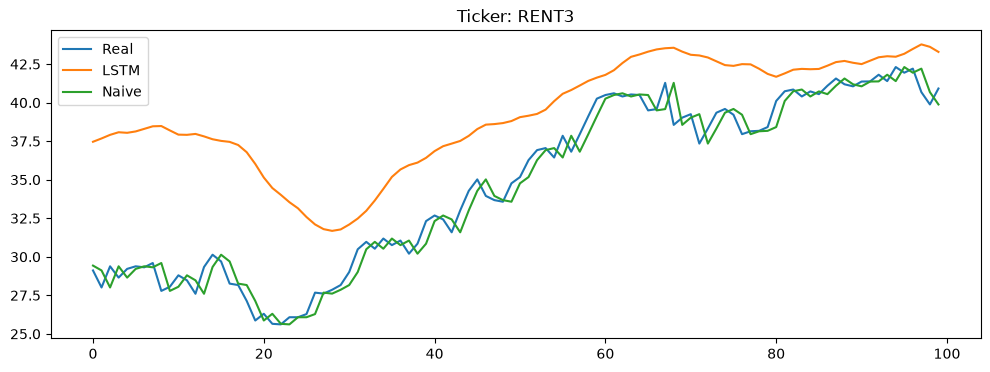

 17%|█▋        | 1/6 [00:35<02:56, 35.38s/it]

Processando para LREN3


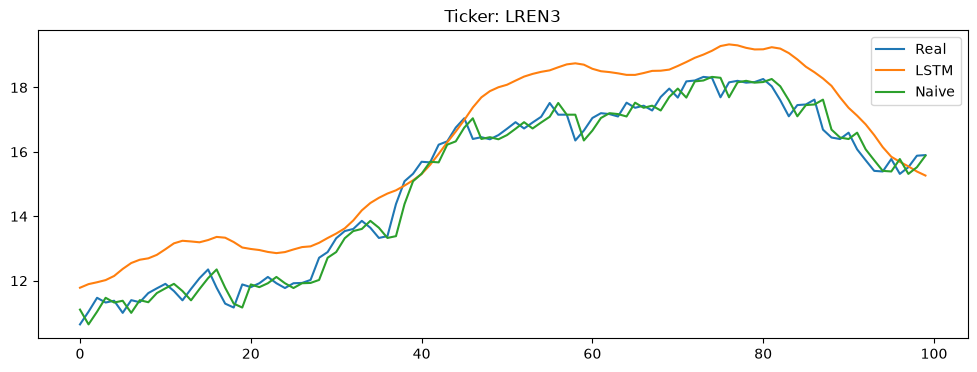

 33%|███▎      | 2/6 [00:45<01:21, 20.28s/it]

Processando para SMFT3


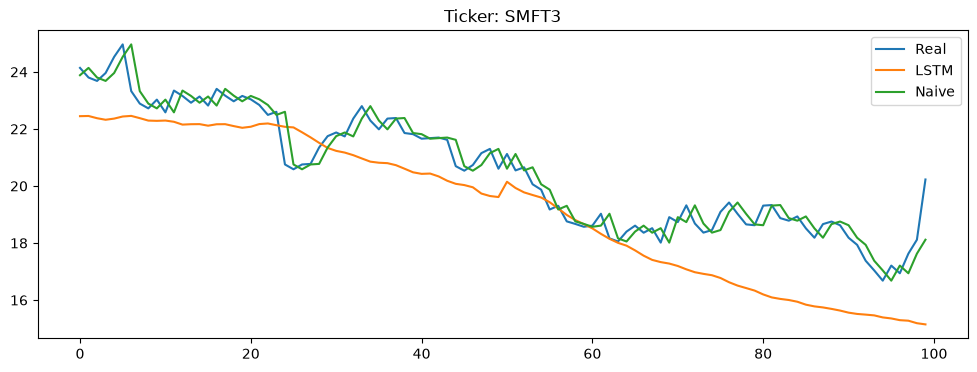

 50%|█████     | 3/6 [00:57<00:50, 16.87s/it]

Processando para MULT3


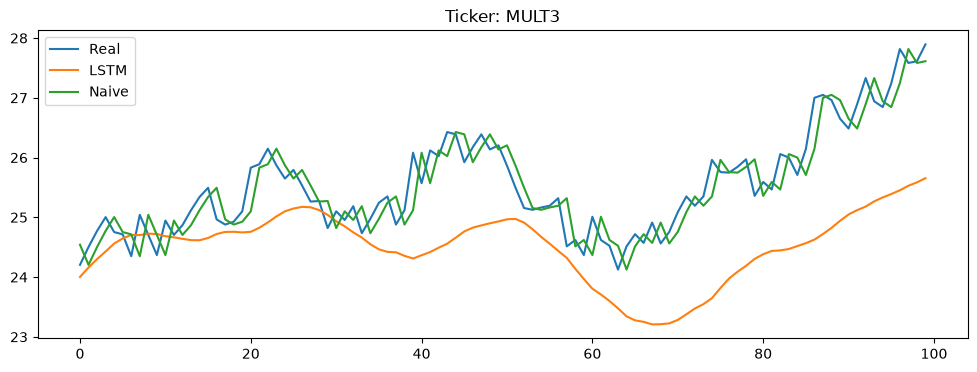

 67%|██████▋   | 4/6 [01:13<00:32, 16.19s/it]

Processando para VBBR3


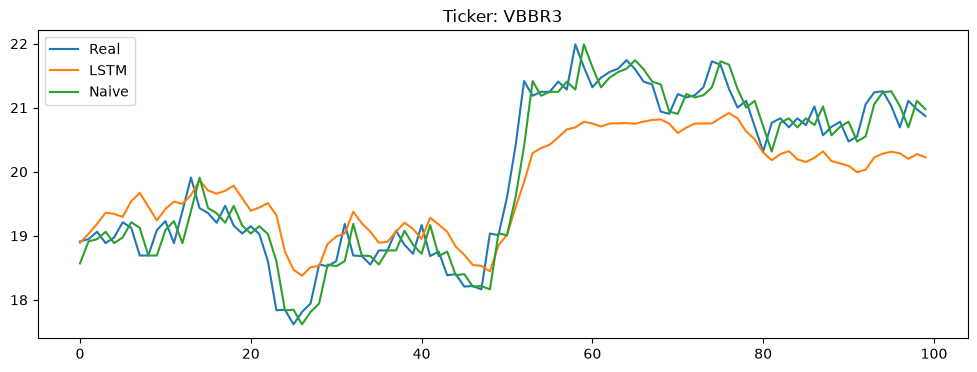

 83%|████████▎ | 5/6 [02:37<00:40, 40.97s/it]

Processando para ABEV3


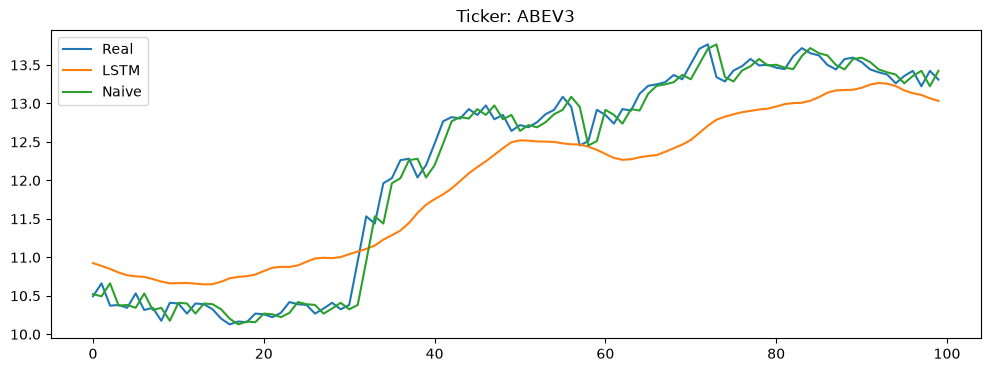

100%|██████████| 6/6 [02:45<00:00, 27.56s/it]


,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
1,LREN3,19.60,17.86,6.84,34.89,0.93,1.14,6.43,6.16,0.50,0.27,0.35,1.85,-2.29,4.73,5.81,False
2,SMFT3,18.75,19.32,3.83,20.42,1.57,1.87,7.93,8.42,0.13,0.37,0.50,1.85,-2.72,8.36,9.99,False
0,RENT3,36.56,39.26,14.61,39.95,3.04,3.93,8.86,8.18,0.60,0.74,1.00,1.88,-2.95,8.33,10.76,False
5,ABEV3,12.42,12.29,1.57,12.60,0.78,1.02,5.52,5.73,0.63,0.14,0.22,1.04,-3.70,6.26,8.17,False
3,MULT3,20.70,20.00,4.08,19.72,2.74,3.39,9.11,9.75,-0.35,0.36,0.48,1.25,-6.09,13.24,16.36,False
4,VBBR3,16.22,15.31,4.45,27.45,4.19,5.81,14.44,16.53,-0.34,0.34,0.47,1.36,-11.41,25.81,35.81,False


In [15]:
resultados = []

for ticker in tqdm(tickers):
    print(f"Processando para {ticker}")

    df = pd.read_parquet(f"dados/refined/tb_analitica_{ticker}.parquet")
    df = df.dropna()
    df = df.sort_values("date").reset_index(drop=True)

    hiperparams = tabela_hiperparams[tabela_hiperparams['ticker'] == ticker].drop(columns = ['ticker', 'val_loss_mse']).to_dict(orient = 'records')[0]

    for k, v in hiperparams.items():
        globals()[k] = v
    recurrent_dropout = 0

    media_close = df.close.mean()
    mediana_close = df.close.median()
    desvio_close = df.close.std()
    cv = desvio_close / media_close * 100

    data = df[features].copy()

    # Divisão temporal ANTES do scaler (evita data leakage)
    n = len(data)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = data.iloc[:train_end].copy()
    valid_df = data.iloc[train_end:valid_end].copy()
    test_df  = data.iloc[valid_end:].copy()

    scaler = RobustScaler()
    scaler.fit(train_df)

    train_scaled = scaler.transform(train_df)
    valid_scaled = scaler.transform(valid_df)
    test_scaled  = scaler.transform(test_df)

    X_train, y_train = build_lstm_sequences(window_size, train_scaled)
    X_valid, y_valid = build_lstm_sequences(window_size, valid_scaled)
    X_test, y_test = build_lstm_sequences(window_size, test_scaled)

    model = generate_lstm_model(units_1, dropout, units_2, learning_rate, recurrent_dropout, l2, n_dense, dense_units, optimizer, X_train)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=100,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    naive_scaled = X_test[:, -1, 0]

    dummy_pred = np.zeros((len(pred_scaled), len(features)))
    dummy_real = np.zeros((len(y_test), len(features)))
    dummy_naive = np.zeros((len(naive_scaled), len(features)))

    dummy_pred[:, 0] = pred_scaled.ravel()
    dummy_real[:, 0] = y_test
    dummy_naive[:, 0] = naive_scaled

    pred = scaler.inverse_transform(dummy_pred)[:, 0]
    real = scaler.inverse_transform(dummy_real)[:, 0]
    naive = scaler.inverse_transform(dummy_naive)[:, 0]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = mean_absolute_percentage_error(real, pred) * 100
    r2 = r2_score(real, pred)
    sm = smape(real, pred)

    mae_n = mean_absolute_error(real, naive)
    rmse_n = np.sqrt(mean_squared_error(real, naive))
    mape_n = mean_absolute_percentage_error(real, naive) * 100

    skill = 1 - rmse / rmse_n

    resultados.append({
        "Ticker": ticker,
        "Media": media_close,
        "Mediana": mediana_close,
        "Desvio": desvio_close,
        "CV (%)": cv,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": sm,
        "R2": r2,
        "MAE Naive": mae_n,
        "RMSE Naive": rmse_n,
        "MAPE Naive (%)": mape_n,
        "Skill RMSE": skill,
        "MAE/Media (%)": mae / media_close * 100,
        "RMSE/Media (%)": rmse / media_close * 100,
        "Melhor que Naive": skill > 0
    })

    plt.figure(figsize=(12,4))

    plt.plot(real[:100], label="Real")
    plt.plot(pred[:100], label="LSTM")
    plt.plot(naive[:100], label="Naive")
    plt.title(f'Ticker: {ticker}')

    plt.legend()
    plt.show()

resultado_final = pd.DataFrame(resultados).sort_values(
    "Skill RMSE", ascending=False
)

display(resultado_final)
# resultado_final.to_excel(
#     "dados/refined/resultado_modelos_lstm_2.xlsx",
#     index=False
# )

In [46]:
# resultado_final.round(2).to_dict(orient = 'records')

## 2º teste do modelo

In [47]:
features = [
    "close",
    "volume",
    "close_dolar",
    "close_ibovespa",
    "close_sp_500",
    "selic",
    "ipca",
    "rsi_wilder",
    "macd",
    "macd_signal",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
]

In [ ]:
resultados = []

for ticker in tqdm(tickers):
    print(f"Processando para {ticker}")

    df = pd.read_parquet(f"dados/refined/tb_analitica_{ticker}.parquet")
    df = df[df['close'].notna()]
    df = df.sort_values("date").reset_index(drop=True)

    hiperparams = tabela_hiperparams[tabela_hiperparams['ticker'] == ticker].drop(columns = ['ticker', 'val_loss']).to_dict(orient = 'records')[0]

    for k, v in hiperparams.items():
        globals()[k] = v

    media_close = df.close.mean()
    mediana_close = df.close.median()
    desvio_close = df.close.std()
    cv = desvio_close / media_close * 100

    data = df[features].copy()

    # ==============================================================================
    # Split temporal do DataFrame
    # ==============================================================================

    n = len(data)

    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = data.iloc[:train_end].copy()
    valid_df = data.iloc[train_end:valid_end].copy()
    test_df  = data.iloc[valid_end:].copy()

    # ==============================================================================
    # Normalização
    # O scaler é ajustado SOMENTE nos dados de treino
    # ==============================================================================

    scaler = RobustScaler()

    scaler.fit(train_df)

    train_scaled = scaler.transform(train_df)
    valid_scaled = scaler.transform(valid_df)
    test_scaled  = scaler.transform(test_df)

    # ==============================================================================
    # Construção das sequências
    # Cada conjunto gera suas próprias sequências
    # ==============================================================================

    X_train, y_train = build_lstm_sequences(
        window_size=window_size,
        scaled_data=train_scaled
    )

    X_valid, y_valid = build_lstm_sequences(
        window_size=window_size,
        scaled_data=valid_scaled
    )

    X_test, y_test = build_lstm_sequences(
        window_size=window_size,
        scaled_data=test_scaled
    )

    model = generate_lstm_model(
        units_1, dropout, units_2, learning_rate, X_train
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=100,
        batch_size=batch_size,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    naive_scaled = X_test[:, -1, 0]

    dummy_pred = np.zeros((len(pred_scaled), len(features)))
    dummy_real = np.zeros((len(y_test), len(features)))
    dummy_naive = np.zeros((len(naive_scaled), len(features)))

    dummy_pred[:, 0] = pred_scaled.ravel()
    dummy_real[:, 0] = y_test
    dummy_naive[:, 0] = naive_scaled

    pred = scaler.inverse_transform(dummy_pred)[:, 0]
    real = scaler.inverse_transform(dummy_real)[:, 0]
    naive = scaler.inverse_transform(dummy_naive)[:, 0]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = mean_absolute_percentage_error(real, pred) * 100
    r2 = r2_score(real, pred)
    sm = smape(real, pred)

    mae_n = mean_absolute_error(real, naive)
    rmse_n = np.sqrt(mean_squared_error(real, naive))
    mape_n = mean_absolute_percentage_error(real, naive) * 100

    skill = 1 - rmse / rmse_n

    resultados.append({
        "Ticker": ticker,
        "Media": media_close,
        "Mediana": mediana_close,
        "Desvio": desvio_close,
        "CV (%)": cv,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": sm,
        "R2": r2,
        "MAE Naive": mae_n,
        "RMSE Naive": rmse_n,
        "MAPE Naive (%)": mape_n,
        "Skill RMSE": skill,
        "MAE/Media (%)": mae / media_close * 100,
        "RMSE/Media (%)": rmse / media_close * 100,
        "Melhor que Naive": skill > 0
    })

resultado_final = pd.DataFrame(resultados).sort_values(
    "Skill RMSE", ascending=False
)

display(resultado_final)
resultado_final.to_excel(
    "dados/refined/resultado_modelos_lstm_2.xlsx",
    index=False
)

  0%|          | 0/6 [00:00<?, ?it/s]g:\Meu Drive\5. Cursos\Pós ML Engineering\Fase 4 - Deep Learning e IA\lstm-stock-predictor-api\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processando para RENT3


 17%|█▋        | 1/6 [01:45<08:48, 105.72s/it]g:\Meu Drive\5. Cursos\Pós ML Engineering\Fase 4 - Deep Learning e IA\lstm-stock-predictor-api\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processando para LREN3


 33%|███▎      | 2/6 [02:15<04:04, 61.05s/it] g:\Meu Drive\5. Cursos\Pós ML Engineering\Fase 4 - Deep Learning e IA\lstm-stock-predictor-api\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Processando para VBBR3


 83%|████████▎ | 5/6 [06:16<01:28, 88.15s/it]g:\Meu Drive\5. Cursos\Pós ML Engineering\Fase 4 - Deep Learning e IA\lstm-stock-predictor-api\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processando para ABEV3


100%|██████████| 6/6 [06:42<00:00, 67.07s/it]


,Ticker,Media,Mediana,Desvio,CV (%),MAE,RMSE,MAPE (%),sMAPE (%),R2,MAE Naive,RMSE Naive,MAPE Naive (%),Skill RMSE,MAE/Media (%),RMSE/Media (%),Melhor que Naive
2,SMFT3,19.01,19.63,3.97,20.86,2.18,2.97,9.77,10.63,-0.75,0.39,0.54,1.91,-4.52,11.49,15.61,False
0,RENT3,36.02,38.82,14.95,41.49,6.58,7.79,14.52,16.03,-1.56,0.82,1.10,1.88,-6.12,18.26,21.63,False
5,ABEV3,12.43,12.33,1.55,12.48,1.53,1.95,10.55,11.31,-0.48,0.15,0.23,1.05,-7.49,12.29,15.64,False
1,LREN3,19.48,17.65,6.83,35.04,6.48,6.53,45.62,36.97,-66.56,0.26,0.34,1.81,-18.44,33.26,33.51,False
3,MULT3,20.60,19.88,4.10,19.88,9.54,9.95,32.68,39.42,-11.24,0.36,0.49,1.25,-19.43,46.30,48.32,False
4,VBBR3,16.12,15.20,4.44,27.57,14.17,14.53,48.38,64.22,-19.44,0.43,0.57,1.48,-24.59,87.88,90.11,False


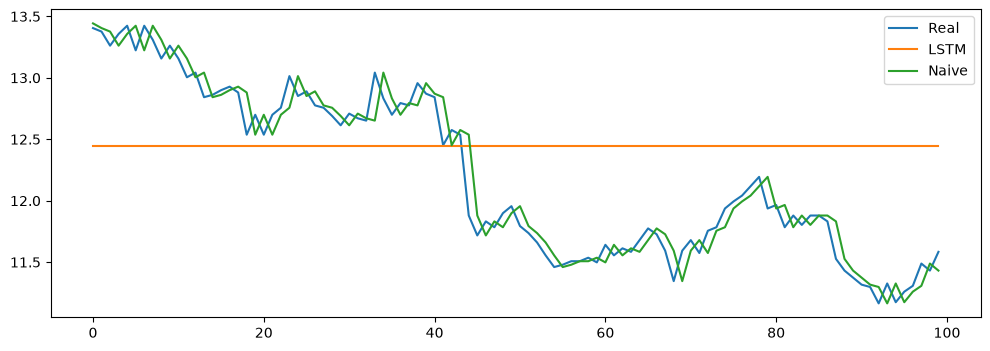

In [51]:
plt.figure(figsize=(12,4))

plt.plot(real[:100], label="Real")
plt.plot(pred[:100], label="LSTM")
plt.plot(naive[:100], label="Naive")

plt.legend()